## Line Extents — endpoints beyond the x limits

What happens when a line drawn on a chart has extremities outside the visible x-range — e.g. a trendline anchored before the window start, or extended past the last bar?

The chart axes use `xmargin 0` with autoscale on, so the x limits come from the data limits at draw time. Any artist that *contributes* to the data limits (like `ax.plot`) will stretch the chart to include its endpoints. This notebook compares the drawing approaches:

1. `ax.plot` — endpoints expand the x limits (the problem)
2. `ax.plot` + pinning the limits back — line clipped at the edges
3. `ax.add_artist(Line2D)` — artist never enters the data limits
4. `ax.axline` — infinite line through two points, clipped at the axes bounds

In [1]:
import numpy as np

from matplotlib.lines import Line2D

from mplchart.chart import Chart
from mplchart.primitives import Candlesticks
from mplchart.samples import sample_prices

In [2]:
prices = sample_prices()
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 11325 entries, 1980-12-12 to 2025-11-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    11325 non-null  float64
 1   high    11325 non-null  float64
 2   low     11325 non-null  float64
 3   close   11325 non-null  float64
 4   volume  11325 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 530.9 KB


### Baseline

A plain chart over the last 250 bars. X-coordinates on the main axes are rownums over the *full* prices frame, so the visible window is roughly `[n - 250, n - 1]`.

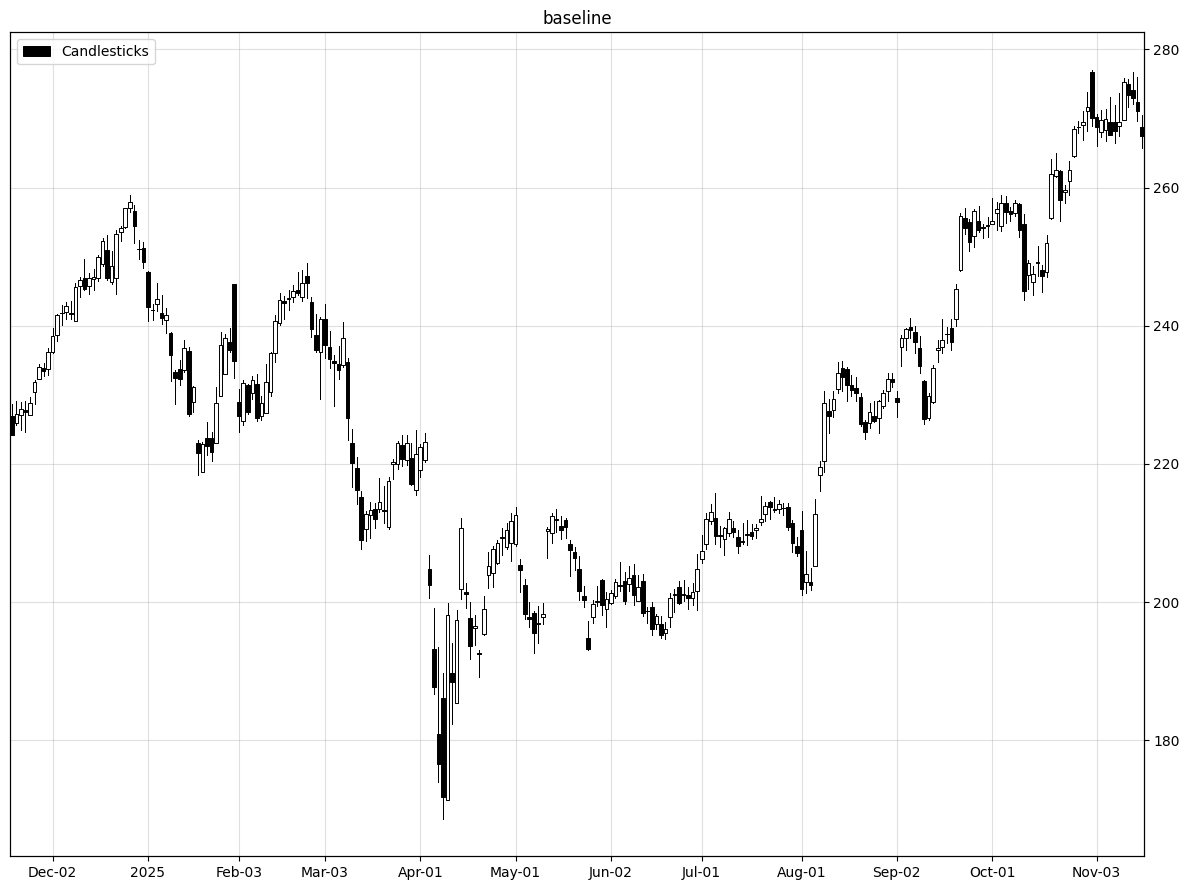

xlim: (np.float64(11074.6), np.float64(11324.4))


In [3]:
n = len(prices)
close = prices["close"].to_numpy()

chart = Chart(prices, title="baseline", max_bars=250)
chart.plot(Candlesticks())
chart.show()

ax = chart.canvas.get_axes()
print("xlim:", ax.get_xlim())

### 1. `ax.plot` — endpoints expand the x limits

Two segments with out-of-range extremities: one anchored 100 bars *before* the window start, one extended 60 bars *past* the last bar. `ax.plot` feeds the endpoints into the data limits, so autoscale stretches the x-axis to include them — the candles get compressed and empty space appears on both sides.

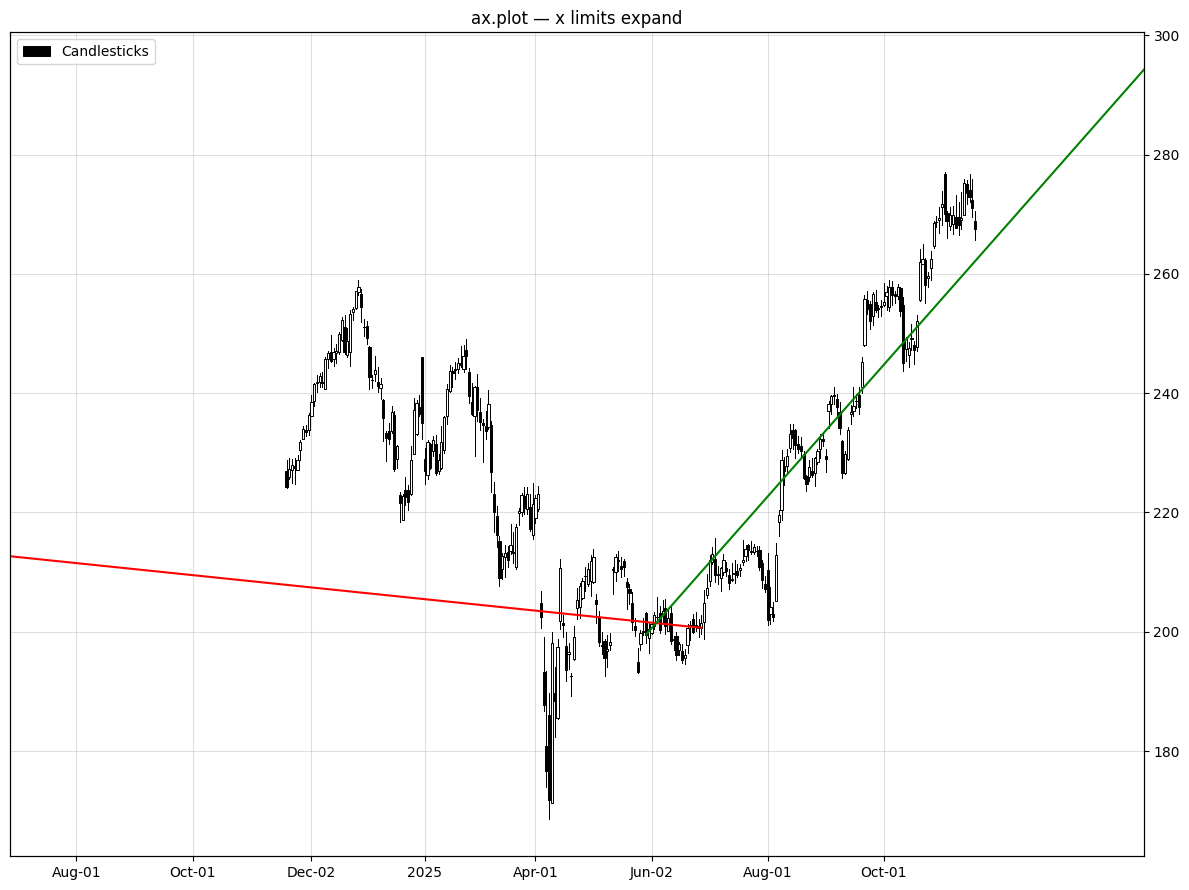

xlim: (np.float64(10975.0), np.float64(11385.0))


In [4]:
chart = Chart(prices, title="ax.plot — x limits expand", max_bars=250)
chart.plot(Candlesticks())
ax = chart.canvas.get_axes()

# anchored before the window start (window starts at n - 250)
xa = [n - 350, n - 100]
ya = [close[n - 350], close[n - 100]]
ax.plot(xa, ya, color="red", linewidth=1.5)

# extended past the last bar
xb = [n - 120, n + 60]
yb = [close[n - 120], close[-1] * 1.1]
ax.plot(xb, yb, color="green", linewidth=1.5)

chart.show()
print("xlim:", ax.get_xlim())

### 2. `ax.plot` + pin the limits back

Same lines, but capture the x limits before drawing and restore them after. A draw is forced first so autoscale has settled on the candles-only limits. The lines are clipped at the axes edges. Note `set_xlim` turns x-autoscale off, so anything plotted afterwards won't expand the axis either.

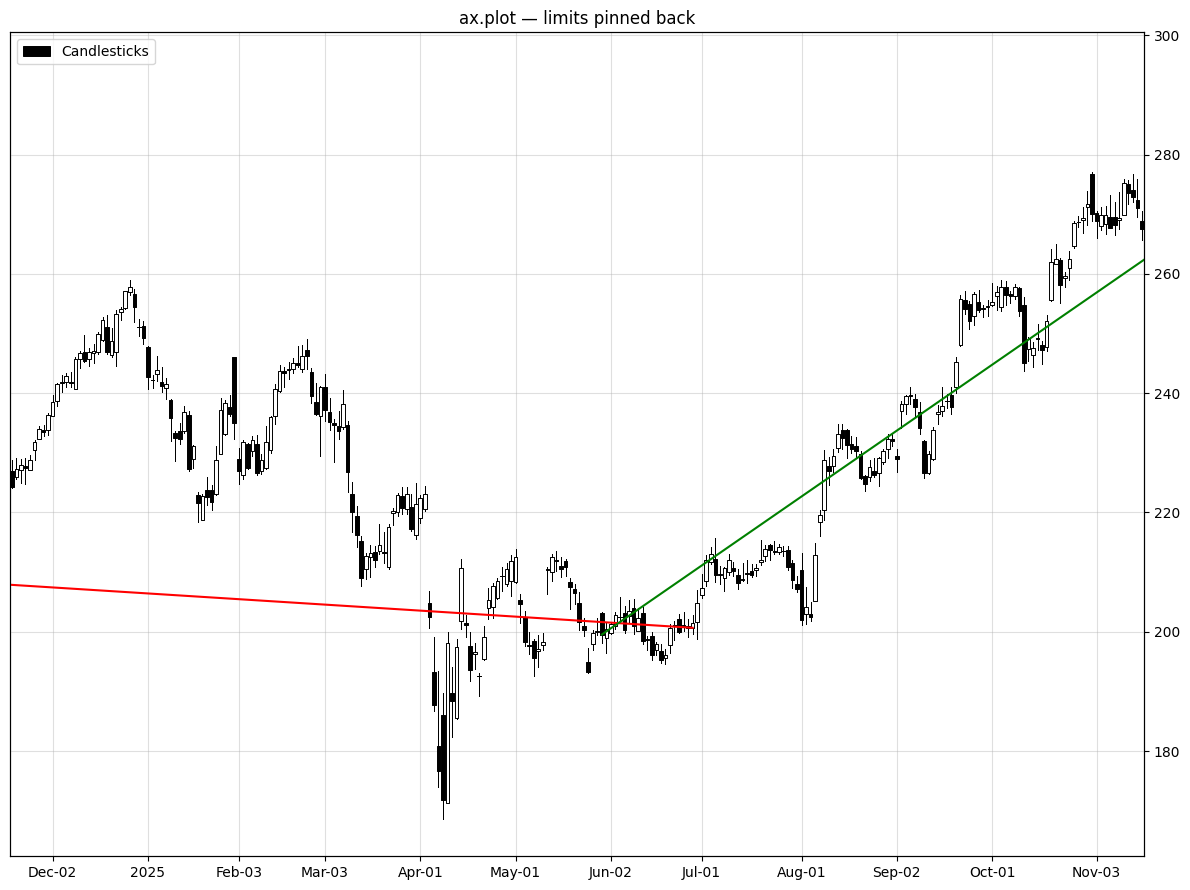

xlim: (np.float64(11074.6), np.float64(11324.4))


In [5]:
chart = Chart(prices, title="ax.plot — limits pinned back", max_bars=250)
chart.plot(Candlesticks())
ax = chart.canvas.get_axes()

ax.figure.canvas.draw()  # settle autoscale on the candles
xlim = ax.get_xlim()

ax.plot(xa, ya, color="red", linewidth=1.5)
ax.plot(xb, yb, color="green", linewidth=1.5)

ax.set_xlim(xlim)
chart.show()
print("xlim:", ax.get_xlim())

### 3. `ax.add_artist(Line2D)` — outside the autoscale

Artists added with `add_artist` never enter the data limits, so the x limits are untouched — no need to capture or restore anything. `add_artist` clips the artist to the axes bbox by default. Autoscale stays on for x.

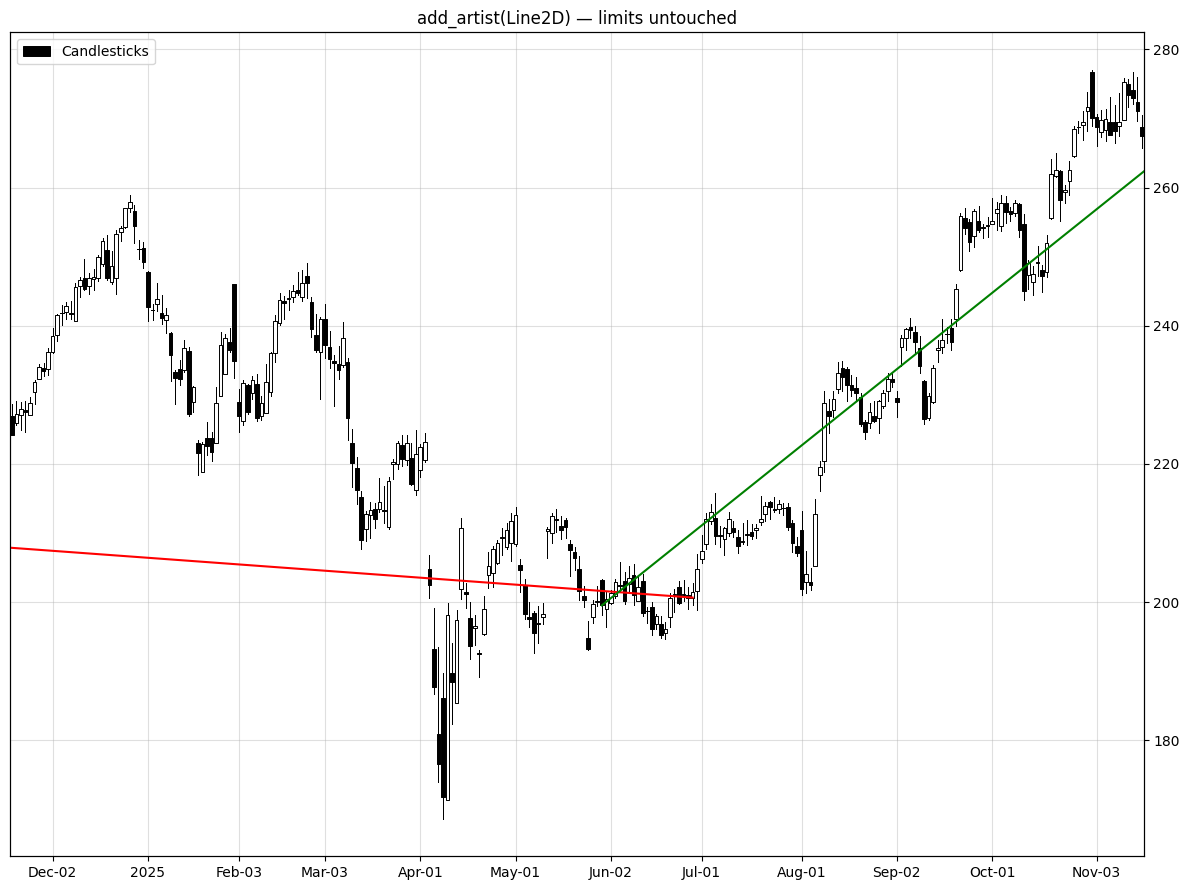

xlim: (np.float64(11074.6), np.float64(11324.4))


In [6]:
chart = Chart(prices, title="add_artist(Line2D) — limits untouched", max_bars=250)
chart.plot(Candlesticks())
ax = chart.canvas.get_axes()

ax.add_artist(Line2D(xa, ya, color="red", linewidth=1.5))
ax.add_artist(Line2D(xb, yb, color="green", linewidth=1.5))

chart.show()
print("xlim:", ax.get_xlim())

### 4. `ax.axline` — infinite line through two points

`axline` draws an unbounded line through two points (or a point and a slope), always spanning the full axes. **Gotcha** (matplotlib 3.10): the *defining points* still enter the data limits — an out-of-range anchor stretches the chart just like `ax.plot`. Here the red line's first anchor sits 100 bars before the window start, and the left limit expands to reach it.

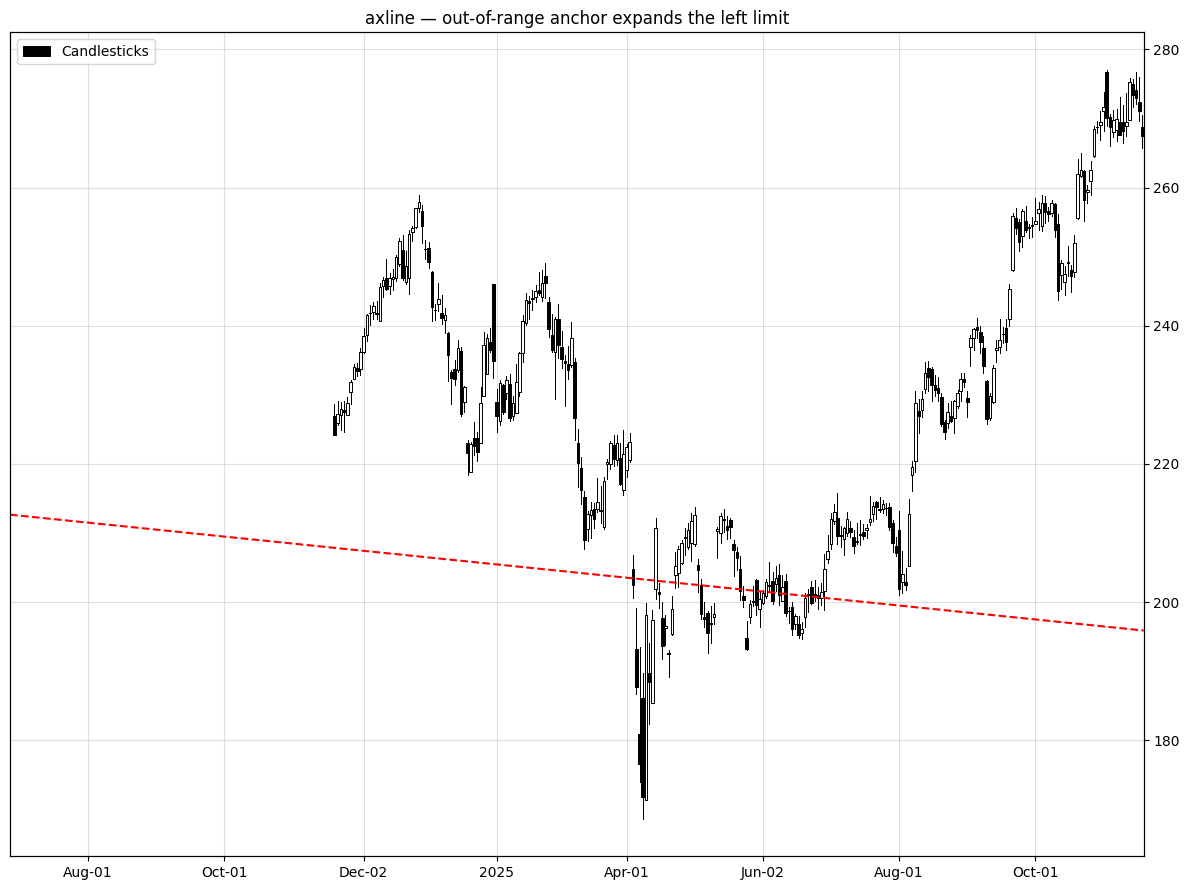

xlim: (np.float64(10975.0), np.float64(11324.4))


In [7]:
chart = Chart(prices, title="axline — out-of-range anchor expands the left limit", max_bars=250)
chart.plot(Candlesticks())
ax = chart.canvas.get_axes()

ax.axline((xa[0], ya[0]), (xa[1], ya[1]), color="red", linewidth=1.5, linestyle="--")

chart.show()
print("xlim:", ax.get_xlim())

### 4b. `ax.axline` — anchored in-range

Since the line is infinite anyway, the geometry doesn't care where the anchors sit — use the point + slope form with an anchor *inside* the visible range and the limits stay put.

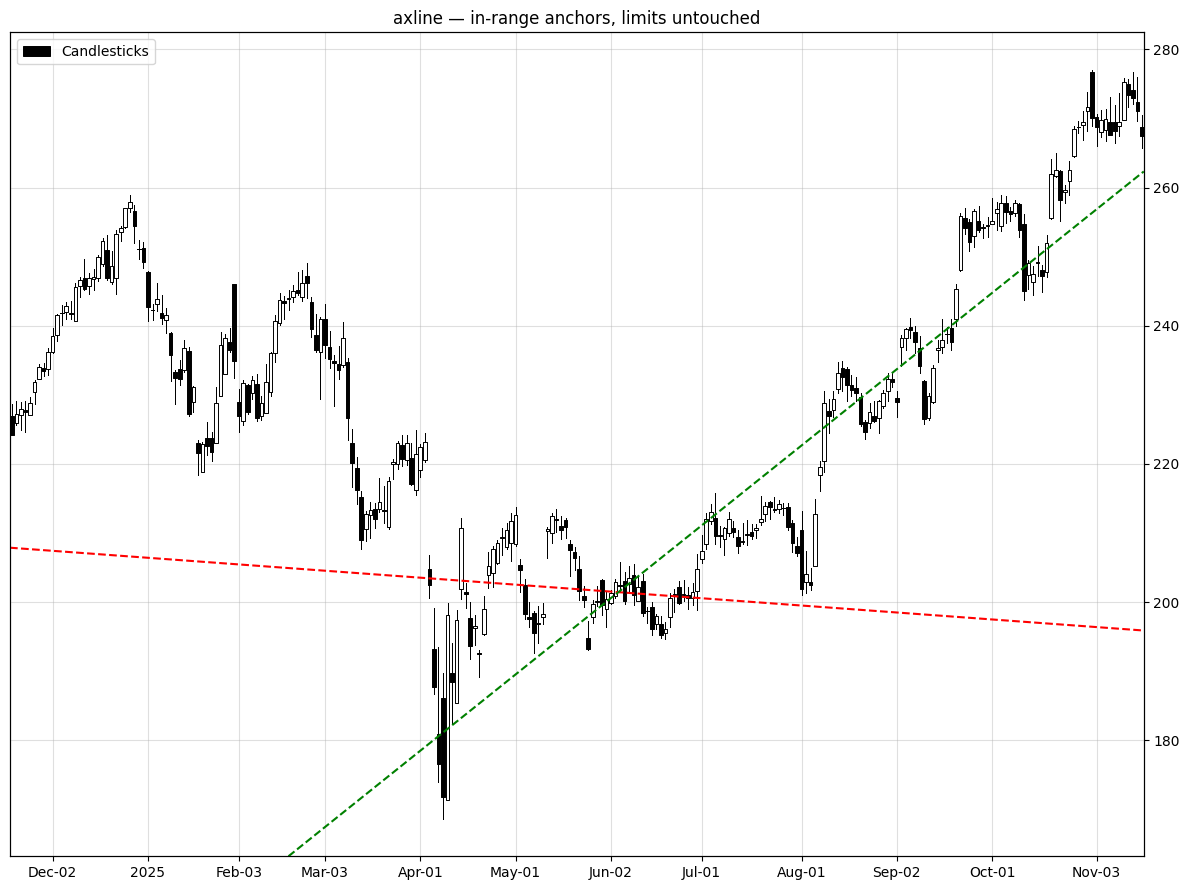

xlim: (np.float64(11074.6), np.float64(11324.4))


In [8]:
chart = Chart(prices, title="axline — in-range anchors, limits untouched", max_bars=250)
chart.plot(Candlesticks())
ax = chart.canvas.get_axes()

# same lines as before, re-anchored at their second (in-window) point
slope_a = (ya[1] - ya[0]) / (xa[1] - xa[0])
ax.axline((xa[1], ya[1]), slope=slope_a, color="red", linewidth=1.5, linestyle="--")

slope_b = (yb[1] - yb[0]) / (xb[1] - xb[0])
ax.axline((xb[0], yb[0]), slope=slope_b, color="green", linewidth=1.5, linestyle="--")

chart.show()
print("xlim:", ax.get_xlim())

### Takeaways

- `ax.plot` endpoints participate in autoscale — out-of-range extremities stretch the chart.
- Pinning limits back (`set_xlim` after a settled draw) works but disables x-autoscale from then on.
- `add_artist(Line2D)` is the cleanest for *segments*: no data-limit impact, clipped at the axes, autoscale untouched.
- `axline` spans the whole chart, but its defining points still enter the data limits — anchor it in-range (point + slope) and it's clean.